In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [10]:
f=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [11]:
f.shape

(7043, 21)

In [12]:
f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
#there is no null value...

In [14]:
f.duplicated().sum()

np.int64(0)

In [15]:
# so there is no duplicate value ....


In [16]:
f.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
# we got the max values and min values

In [18]:
f['TotalCharges'] = pd.to_numeric(f['TotalCharges'], errors='coerce')


In [19]:
f['TotalCharges'].isnull().sum()

np.int64(11)

In [20]:
# so 11 are missiong values

In [21]:
f = f.dropna()

In [22]:
f['TotalCharges'].isnull().sum()

np.int64(0)

In [23]:
f['customerID'].nunique()

7032

In [24]:
f = f.copy()
f['TotalCharges'] = f['TotalCharges'].fillna(f['TotalCharges'].median())

In [25]:
#converting categorical data

In [26]:
f['Churn'] = f['Churn'].map({'Yes':1, 'No':0})

In [27]:
f = pd.get_dummies(f, drop_first=True)

In [28]:
#now after cleaning the data

In [29]:
f.info()
f.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Columns: 7062 entries, SeniorCitizen to PaymentMethod_Mailed check
dtypes: bool(7057), float64(2), int64(3)
memory usage: 47.6 MB


,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
Churn,0
...,...
Contract_Two year,0
PaperlessBilling_Yes,0
PaymentMethod_Credit card (automatic),0
PaymentMethod_Electronic check,0


In [30]:
# ok , all data clear

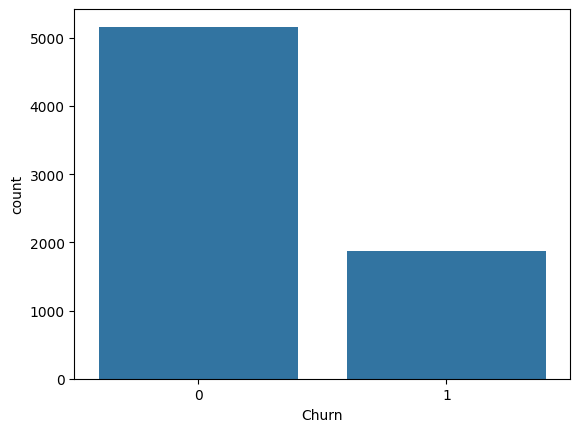

In [31]:
sns.countplot(x='Churn', data=f)
plt.show()

In [32]:
# here most of the customers are stable and
 #approx 1800 customer wants to departure the job.
# . now i want to find out the reason behind it

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

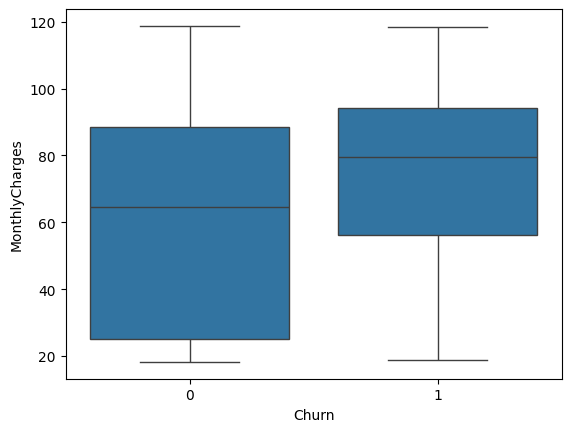

In [33]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=f)

In [34]:
""" customers with higher monthly charges
are more likely to churn than customers with lower monthly charges.
"""

' customers with higher monthly charges \nare more likely to churn than customers with lower monthly charges.\n'

feature engineering

In [35]:
f['AvgCharges'] = f['TotalCharges'] / f['tenure']

train-test split


In [36]:
from sklearn.model_selection import train_test_split

X = f.drop('Churn', axis=1)
y = f['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Model Building


In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Model Evaluation

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8002842928216063
[[935  88]
 [193 191]]


In [39]:
'''The model achieved 79% accuracy, but recall for churn prediction
 is relatively low, meaning many churn customers are not being identified.
  Since churn prediction is a business-critical problem, improving recall
   is more important than accuracy.'''

'The model achieved 79% accuracy, but recall for churn prediction\n is relatively low, meaning many churn customers are not being identified.\n  Since churn prediction is a business-critical problem, improving recall\n   is more important than accuracy.'

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1023
           1       0.68      0.50      0.58       384

    accuracy                           0.80      1407
   macro avg       0.76      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



use Class weight for better recall

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

thershold change

In [42]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [43]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

y_pred_new = (y_prob > 0.3).astype(int)

In [44]:
LogisticRegression(class_weight='balanced')

LogisticRegression(class_weight='balanced')

In [45]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [46]:

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[933  90]
 [203 181]]


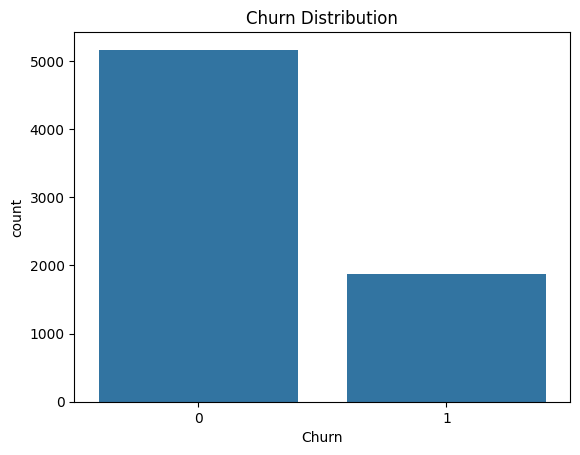

,proportion
Churn,
0,73.421502
1,26.578498


In [48]:
# churn distribution
sns.countplot(x='Churn', data=f)
plt.title("Churn Distribution")
plt.show()

# Percentage
f['Churn'].value_counts(normalize=True) * 100

In [49]:
# majority customers are not churning , which is positive sign  but 26.57 % customers are churning

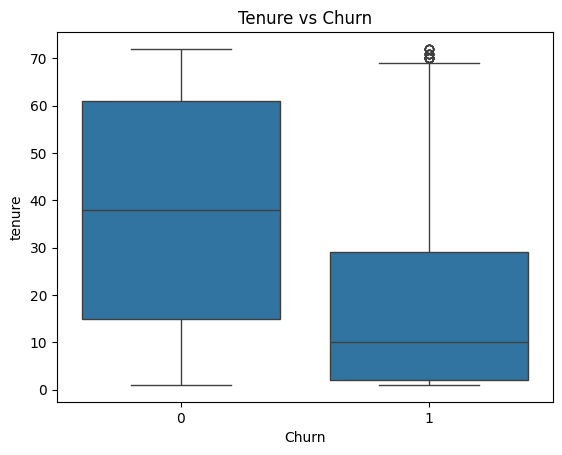

In [50]:
sns.boxplot(x='Churn', y='tenure', data=f)
plt.title("Tenure vs Churn")
plt.show()

In [51]:
'''who churn tend to be newer customer , while long -term customer more
likely to be stay.'''

'who churn tend to be newer customer , while long -term customer more \nlikely to be stay.'

In [52]:
f['tenure_group'] = pd.cut(f['tenure'], bins=[0,12,24,48,72])

pd.crosstab(f['tenure_group'], f['Churn'], normalize='index') * 100

Churn,0,1
tenure_group,,
"(0, 12]",52.321839,47.678161
"(12, 24]",71.289062,28.710938
"(24, 48]",79.611041,20.388959
"(48, 72]",90.486824,9.513176


In [53]:
# if the customer can pass their 1sr and 2nd year , then it will not churn
#from the campany

Implement aggressive and effective onboarding programs, early customer support, and value demonstration during the first 12 months.

 Recognize and reward long-term customers to maintain their satisfaction and further reduce the already low churn in later tenure groups.

In [54]:
first_year = f[f['tenure'] <= 12].copy()

# churn rate
first_year['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,52.321839
1,47.678161


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

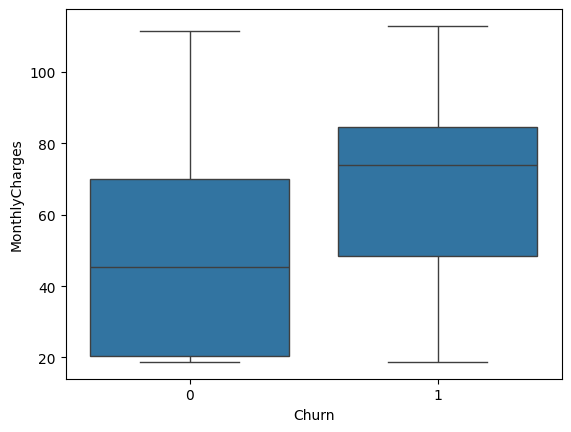

In [58]:
first_year.groupby('Churn')['MonthlyCharges'].mean()

import seaborn as sns
sns.boxplot(x='Churn', y='MonthlyCharges', data=first_year)

#### 1. Churn Distribution

As observed earlier, approximately 26.58% of customers are churning. This indicates a significant number of customers are leaving, highlighting the importance of understanding the underlying causes.

In [64]:
print("Churn Distribution:")
print(df_insights['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


#### 2. Tenure vs. Churn: The Critical First Year

The most significant insight is the relationship between customer `tenure` and `Churn`. Newer customers are far more likely to churn.

Churn Rate by Tenure Group (%):
Churn                 0          1
tenure_group                      
(0, 12]       52.321839  47.678161
(12, 24]      71.289062  28.710938
(24, 48]      79.611041  20.388959
(48, 72]      90.486824   9.513176


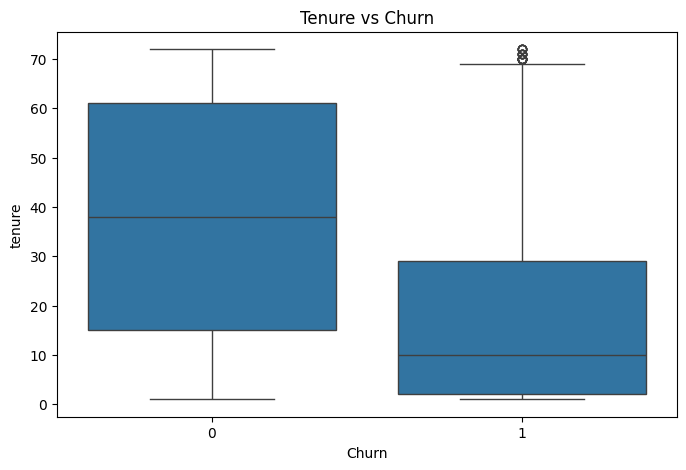


Business Insight: Nearly 50% of customers churn in their first year. Retention efforts should heavily focus on the initial 12 months of a customer's journey.


In [61]:
df_insights['tenure_group'] = pd.cut(df_insights['tenure'], bins=[0,12,24,48,72])
print("Churn Rate by Tenure Group (%):")
print(pd.crosstab(df_insights['tenure_group'], df_insights['Churn'], normalize='index') * 100)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df_insights)
plt.title('Tenure vs Churn')
plt.show()

print("\nBusiness Insight: Nearly 50% of customers churn in their first year. Retention efforts should heavily focus on the initial 12 months of a customer's journey.")

#### 3. MonthlyCharges vs. Churn

Customers with higher monthly charges are more prone to churn.

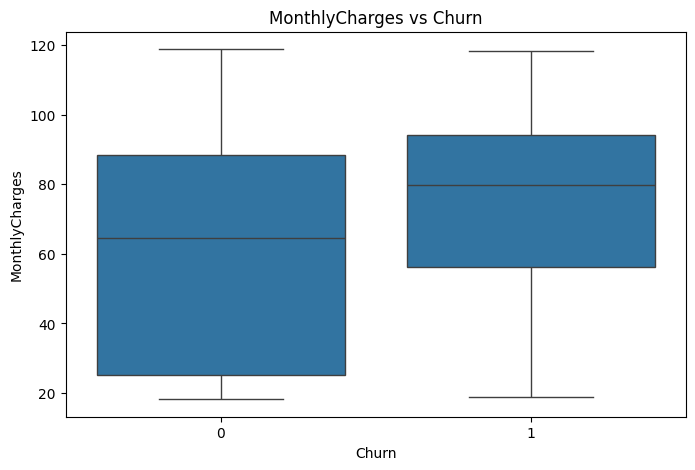


Business Insight: Customers paying higher monthly charges are more likely to churn. This could indicate dissatisfaction with perceived value for money or more attractive competitor offerings at similar price points.


In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_insights)
plt.title('MonthlyCharges vs Churn')
plt.show()
print("\nBusiness Insight: Customers paying higher monthly charges are more likely to churn. This could indicate dissatisfaction with perceived value for money or more attractive competitor offerings at similar price points.")

#### 4. Categorical Feature Analysis vs. Churn

Let's analyze other key categorical features to understand their impact on churn.

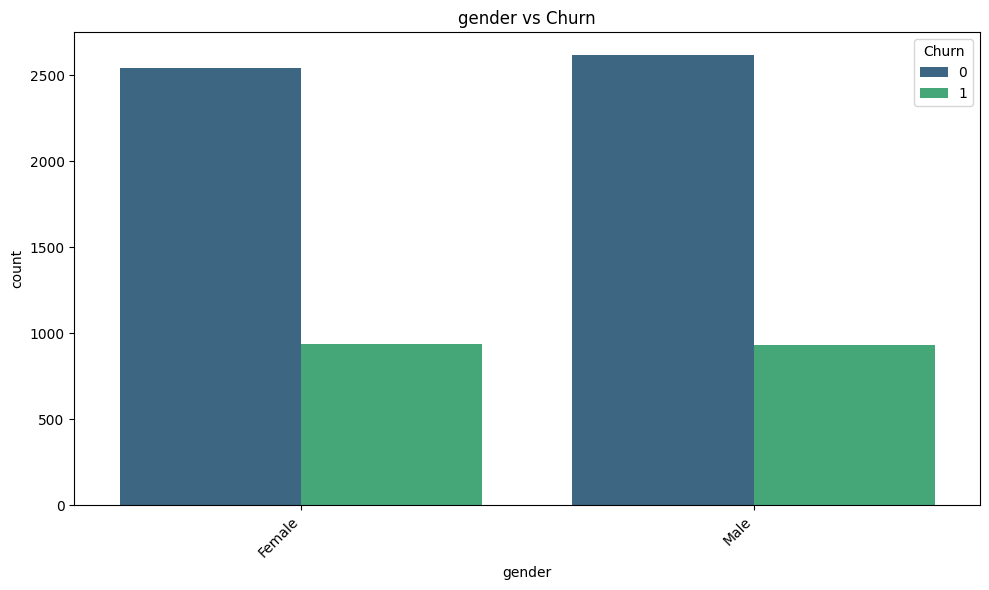


Churn Rate by gender:
gender
Female    26.959518
Male      26.204565
Name: Churn, dtype: float64
--------------------------------------------------


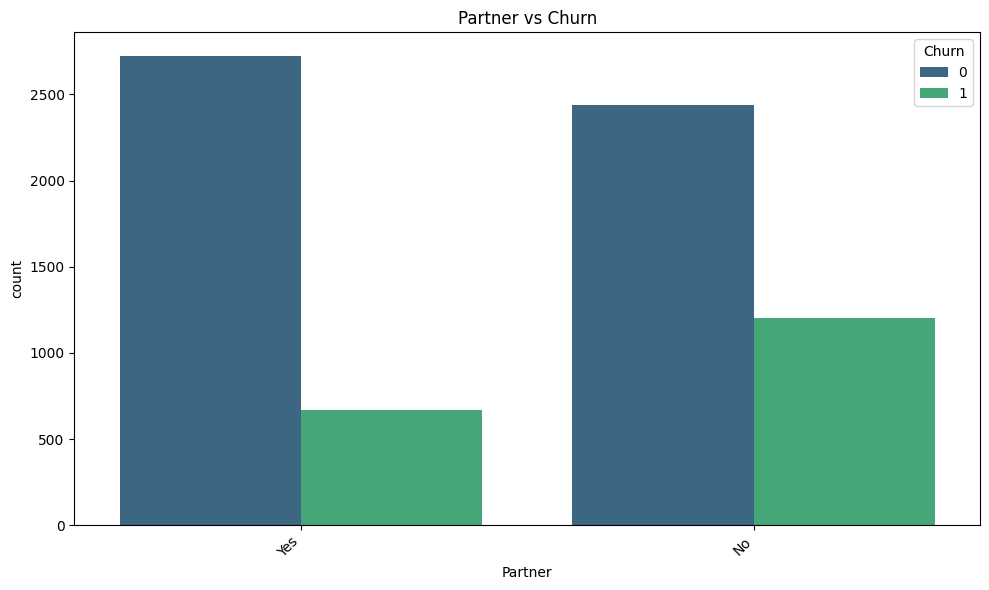


Churn Rate by Partner:
Partner
No     32.976092
Yes    19.717065
Name: Churn, dtype: float64
--------------------------------------------------


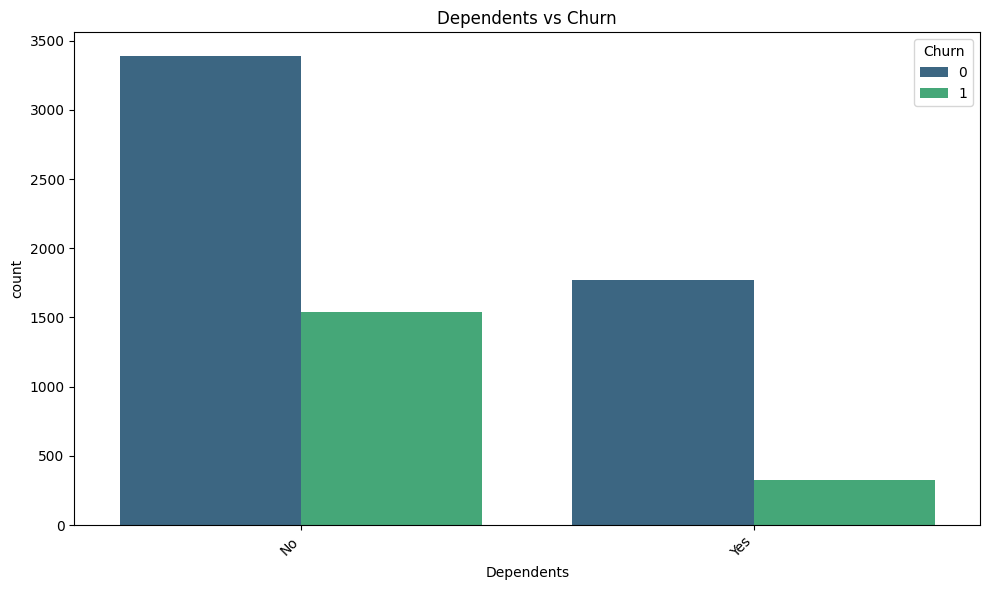


Churn Rate by Dependents:
Dependents
No     31.279140
Yes    15.531205
Name: Churn, dtype: float64
--------------------------------------------------


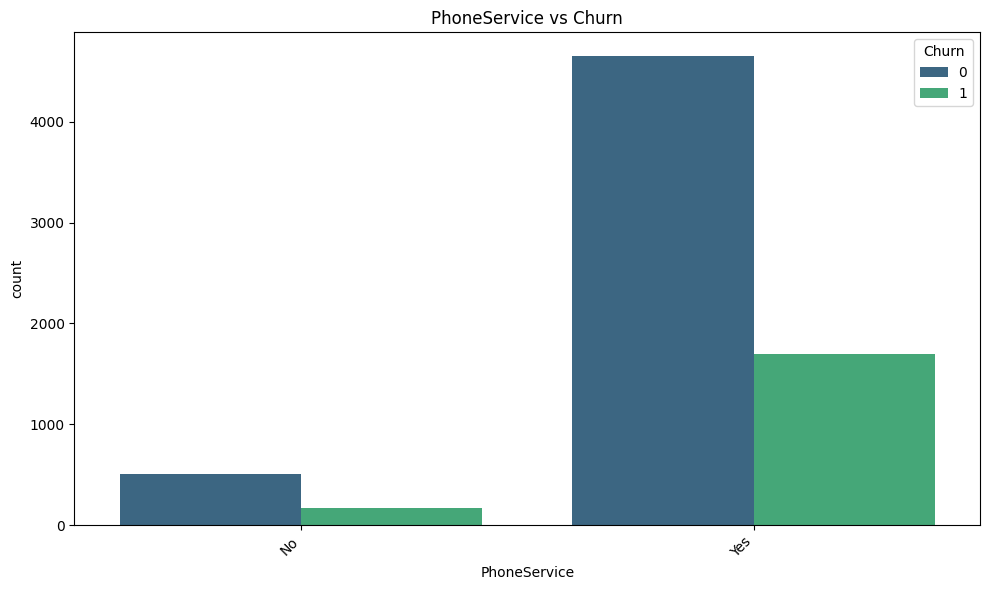


Churn Rate by PhoneService:
PhoneService
No     25.000000
Yes    26.747481
Name: Churn, dtype: float64
--------------------------------------------------


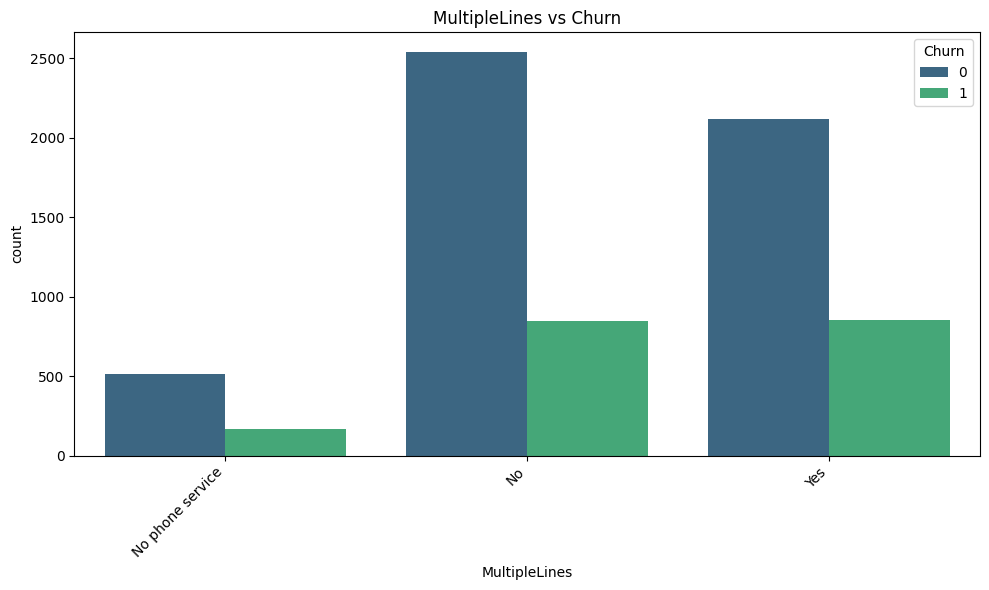


Churn Rate by MultipleLines:
MultipleLines
No                  25.081241
No phone service    25.000000
Yes                 28.648466
Name: Churn, dtype: float64
--------------------------------------------------


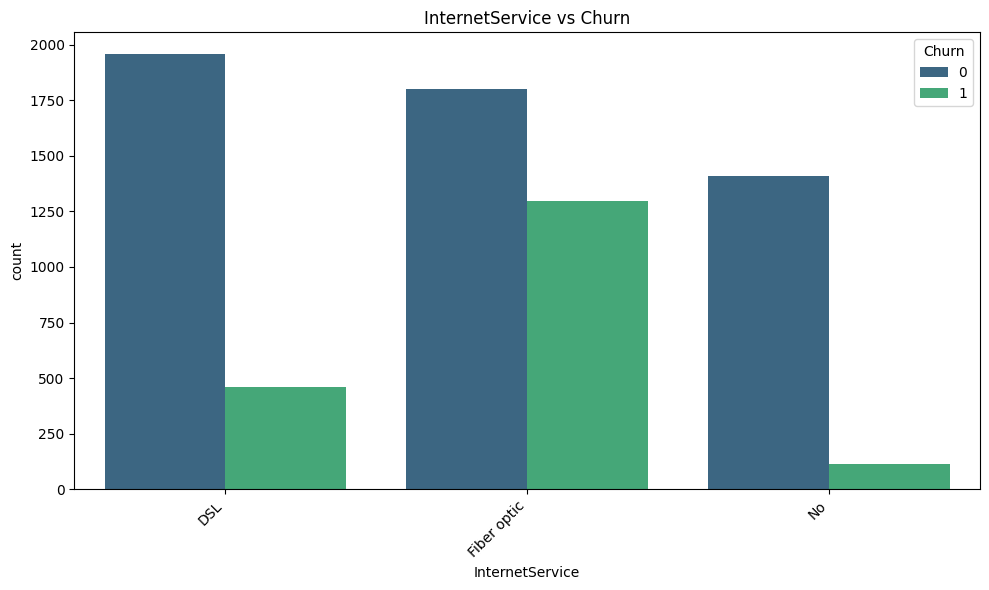


Churn Rate by InternetService:
InternetService
DSL            18.998344
Fiber optic    41.892765
No              7.434211
Name: Churn, dtype: float64
--------------------------------------------------


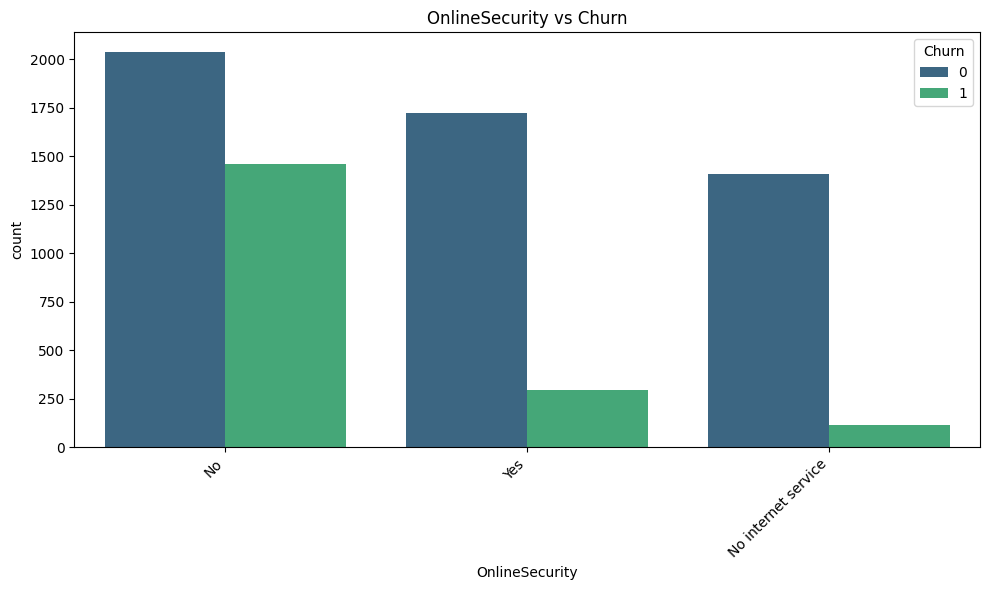


Churn Rate by OnlineSecurity:
OnlineSecurity
No                     41.778667
No internet service     7.434211
Yes                    14.640199
Name: Churn, dtype: float64
--------------------------------------------------


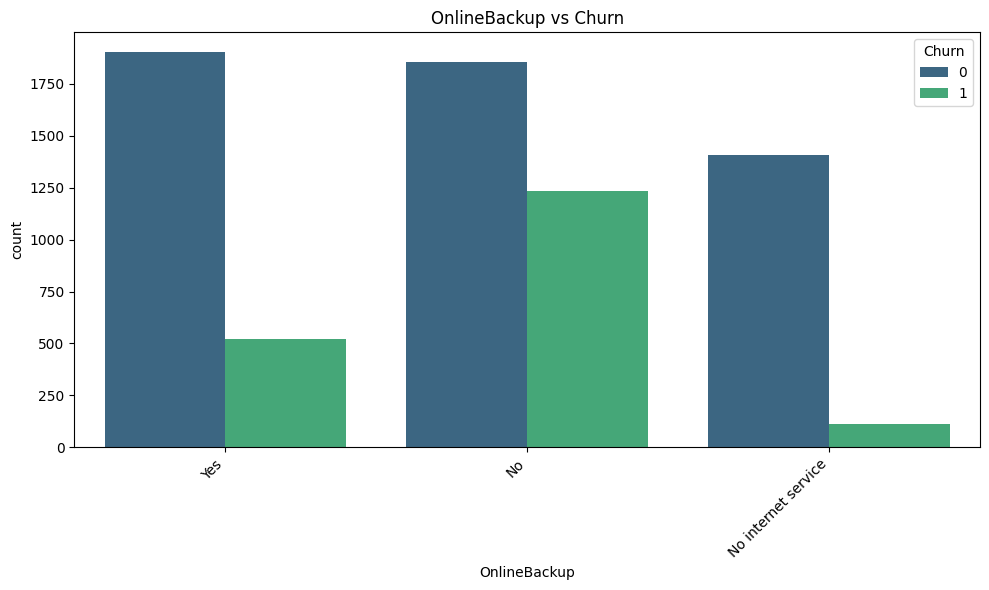


Churn Rate by OnlineBackup:
OnlineBackup
No                     39.941691
No internet service     7.434211
Yes                    21.567010
Name: Churn, dtype: float64
--------------------------------------------------


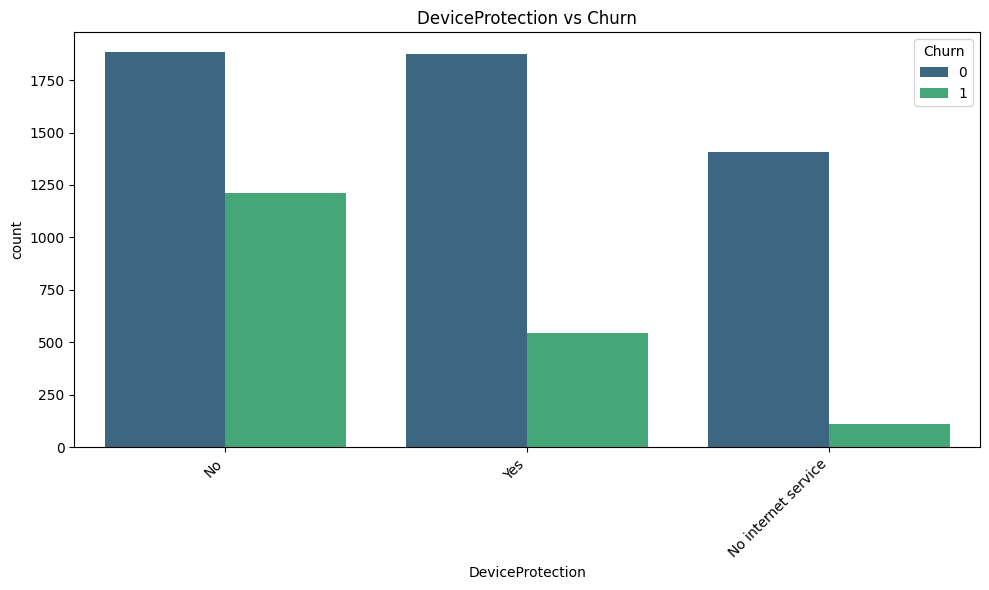


Churn Rate by DeviceProtection:
DeviceProtection
No                     39.140271
No internet service     7.434211
Yes                    22.539289
Name: Churn, dtype: float64
--------------------------------------------------


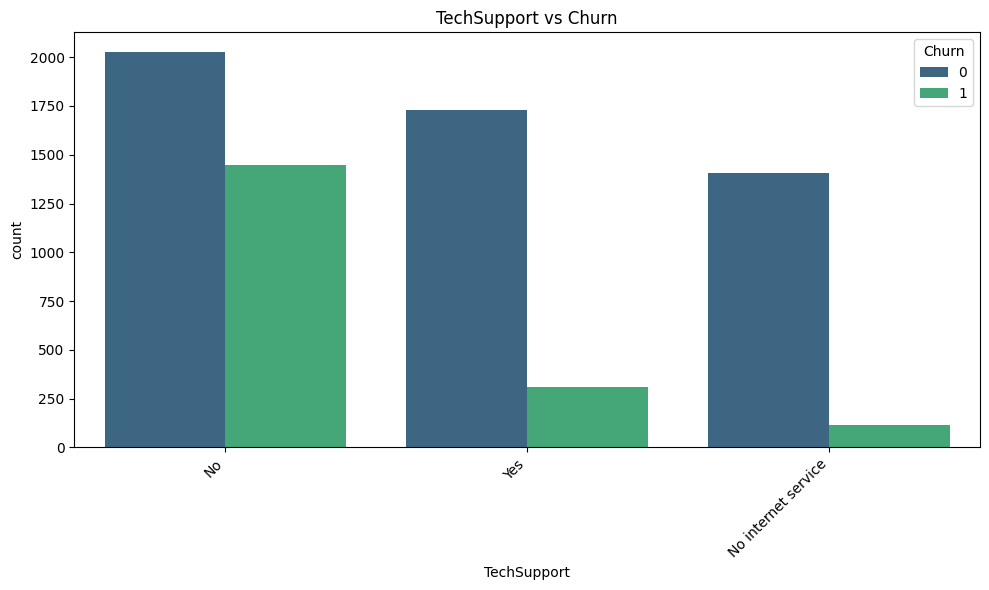


Churn Rate by TechSupport:
TechSupport
No                     41.647465
No internet service     7.434211
Yes                    15.196078
Name: Churn, dtype: float64
--------------------------------------------------


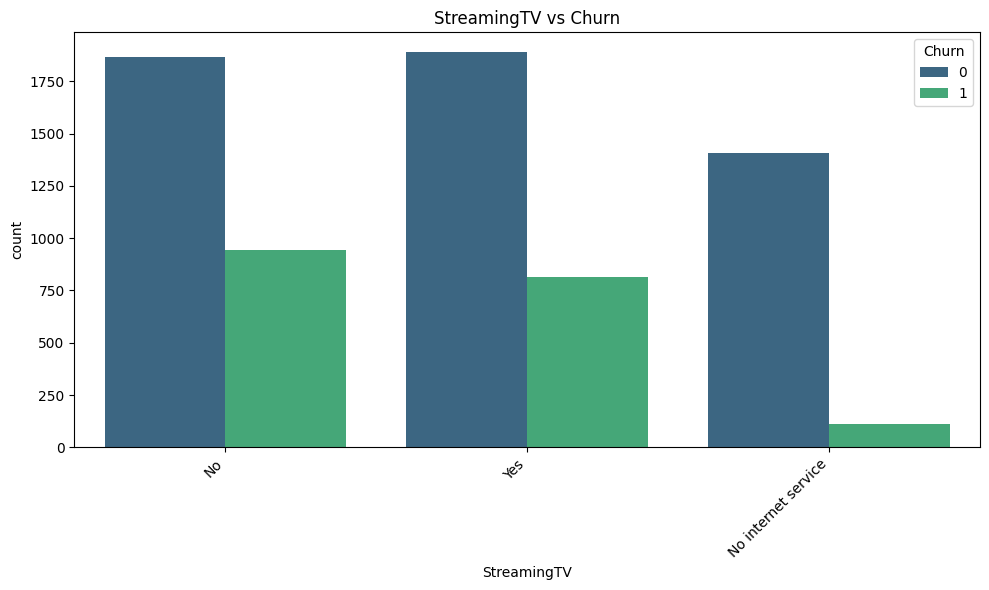


Churn Rate by StreamingTV:
StreamingTV
No                     33.535066
No internet service     7.434211
Yes                    30.114687
Name: Churn, dtype: float64
--------------------------------------------------


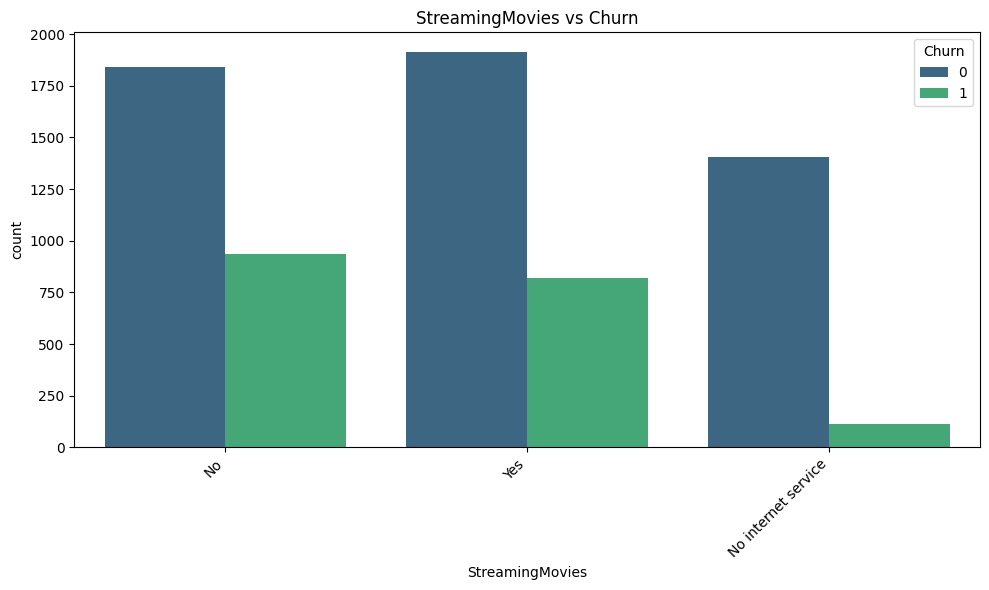


Churn Rate by StreamingMovies:
StreamingMovies
No                     33.728875
No internet service     7.434211
Yes                    29.952398
Name: Churn, dtype: float64
--------------------------------------------------


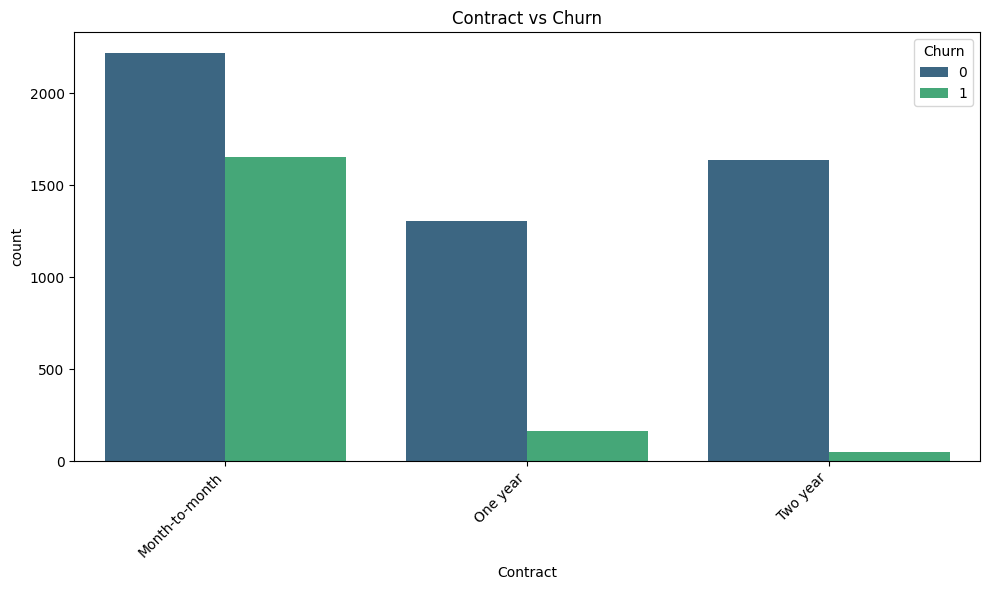


Churn Rate by Contract:
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64
--------------------------------------------------


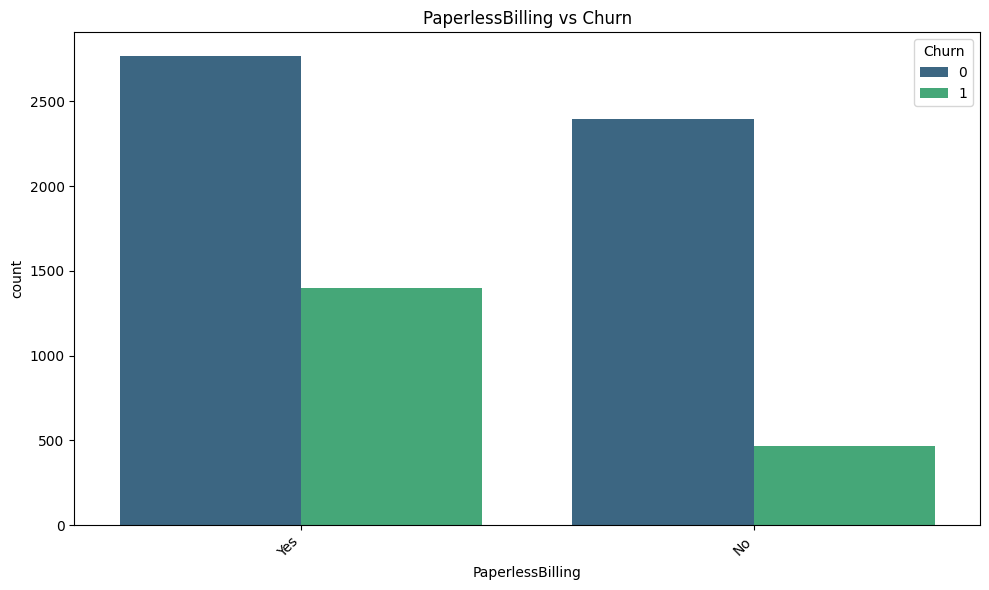


Churn Rate by PaperlessBilling:
PaperlessBilling
No     16.375698
Yes    33.589251
Name: Churn, dtype: float64
--------------------------------------------------


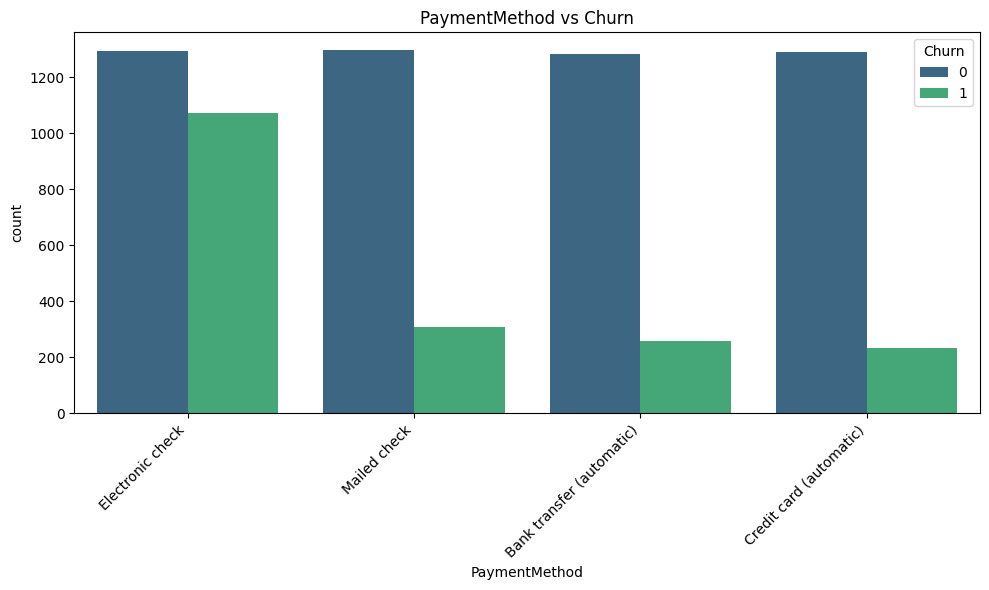


Churn Rate by PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.285412
Mailed check                 19.201995
Name: Churn, dtype: float64
--------------------------------------------------


In [65]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='Churn', data=df_insights, palette='viridis')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    churn_rate = df_insights.groupby(col)['Churn'].mean() * 100
    print(f"\nChurn Rate by {col}:")
    print(churn_rate)
    print("--------------------------------------------------")

Customer Churn – Key Insights

. First-Year Risk: ~50% churn happens within first 12 months → onboarding & early experience weak

.High Charges: Higher MonthlyCharges → higher churn (value dissatisfaction)

. Fiber Optic Issue: Fiber users show higher churn → possible service quality/expectation gap

. Low Service Adoption: No Tech Support / Security / Backup → higher churn (low stickiness)

. Contract Impact: Month-to-month contracts → highest churn; long-term → lower churn

. Payment Method: Electronic check users → higher churn (payment friction)

.  Customer Profile: Single customers (no partner/dependents) → higher churn

BUSINESS ACTION

. Improve onboarding + first-year engagement

. Offer discounts/value plans for high-charge customers

. Fix fiber service issues

. Promote add-on services (support/security)

. Push long-term contracts with incentives

. Encourage auto-pay / better payment methods